# Exploration — PA Metadata (Presence-Absence)

Fichiers concernés :
- `data/GLC25_PA_metadata_train.csv`
- `data/GLC25_PA_metadata_test.csv`

Ces fichiers contiennent les métadonnées des relevés Présence-Absence (PA) : localisation géographique, année, région, pays, et pour le train les espèces observées (`speciesId`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = '/data/challenge2026MIASHS/GLC24-PA/'

train = pd.read_csv(DATA_DIR + 'GLC25_PA_metadata_train.csv')
test  = pd.read_csv(DATA_DIR + 'GLC25_PA_metadata_test.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/GLC25_P0_metadata_train.csv'

## 1. Structure des données

In [3]:
print('=== TRAIN ===')
print(train.dtypes)
train.head(5)

=== TRAIN ===
lon                  float64
lat                  float64
year                   int64
geoUncertaintyInM    float64
areaInM2             float64
region                object
country               object
speciesId            float64
surveyId               int64
dtype: object


,lon,lat,year,geoUncertaintyInM,areaInM2,region,country,speciesId,surveyId
0,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,6874.0,212
1,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,476.0,212
2,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,11157.0,212
3,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,8784.0,212
4,3.099038,43.134956,2021,5.0,100.0,MEDITERRANEAN,France,4530.0,212


In [4]:
print('=== TEST ===')
print(test.dtypes)
test.head(5)

=== TEST ===
lon                  float64
lat                  float64
year                   int64
geoUncertaintyInM    float64
areaInM2             float64
region                object
country               object
surveyId               int64
dtype: object


,lon,lat,year,geoUncertaintyInM,areaInM2,region,country,surveyId
0,10.033550,57.12081,2019,10.0,707.0,CONTINENTAL,Denmark,642
1,7.333000,46.22997,2019,NaN,10.0,ALPINE,Switzerland,1792
2,1.843658,42.58006,2018,0.0,-inf,ALPINE,France,3256
3,11.720090,46.26149,2021,10.0,35.0,ALPINE,Italy,3855
4,9.361870,55.90245,2017,10.0,79.0,CONTINENTAL,Denmark,4889


## 2. Valeurs manquantes

In [5]:
print('=== Valeurs manquantes TRAIN ===')
print(train.isnull().sum())
print('\n=== Valeurs manquantes TEST ===')
print(test.isnull().sum())

=== Valeurs manquantes TRAIN ===
lon                       0
lat                       0
year                      0
geoUncertaintyInM     12496
areaInM2             183272
region                    0
country                   0
speciesId                 0
surveyId                  0
dtype: int64

=== Valeurs manquantes TEST ===
lon                    0
lat                    0
year                   0
geoUncertaintyInM    840
areaInM2             644
region                 0
country                0
surveyId               0
dtype: int64


## 3. Statistiques descriptives

In [6]:
train.describe()

,lon,lat,year,geoUncertaintyInM,areaInM2,speciesId,surveyId
count,1.483637e+06,1.483637e+06,1.483637e+06,1.471141e+06,1300365.0,1.483637e+06,1.483637e+06
mean,9.024850e+00,5.242552e+01,2.018179e+03,7.483046e+00,-inf,5.811442e+03,1.969927e+06
std,4.437247e+00,4.853112e+00,1.094525e+00,6.190821e+00,NaN,3.392812e+03,1.135967e+06
min,-9.018346e+00,3.511705e+01,2.017000e+03,0.000000e+00,-inf,2.000000e+00,2.120000e+02
25%,6.052593e+00,4.856769e+01,2.017000e+03,3.000000e+00,25.0,2.847000e+03,9.768390e+05
50%,9.380850e+00,5.515287e+01,2.018000e+03,1.000000e+01,79.0,6.079000e+03,1.976273e+06
75%,1.041882e+01,5.626047e+01,2.019000e+03,1.000000e+01,79.0,8.818000e+03,2.960059e+06
max,2.915421e+01,5.989300e+01,2.021000e+03,1.000000e+02,8000.0,1.125400e+04,3.919655e+06


## 4. Surveys uniques et espèces

In [7]:
n_surveys_train = train['surveyId'].nunique()
n_species_train = train['speciesId'].nunique()
n_surveys_test  = test['surveyId'].nunique()

print(f'Train — surveys uniques : {n_surveys_train}')
print(f'Train — espèces uniques : {n_species_train}')
print(f'Test  — surveys uniques : {n_surveys_test}')

# Nb observations par survey (train)
obs_per_survey = train.groupby('surveyId')['speciesId'].count()
print(f'\nNb espèces par survey (train) — min: {obs_per_survey.min()}, max: {obs_per_survey.max()}, mean: {obs_per_survey.mean():.2f}')

Train — surveys uniques : 88987
Train — espèces uniques : 5016
Test  — surveys uniques : 14784

Nb espèces par survey (train) — min: 1, max: 837, mean: 16.67


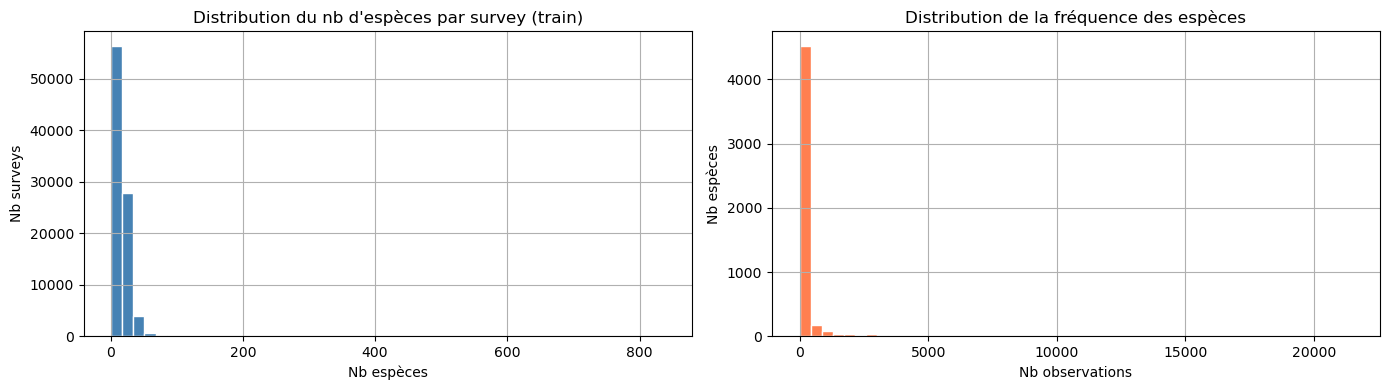

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

obs_per_survey.hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du nb d\'espèces par survey (train)')
axes[0].set_xlabel('Nb espèces')
axes[0].set_ylabel('Nb surveys')

species_freq = train['speciesId'].value_counts()
species_freq.hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribution de la fréquence des espèces')
axes[1].set_xlabel('Nb observations')
axes[1].set_ylabel('Nb espèces')

plt.tight_layout()
plt.show()

## 5. Distribution géographique

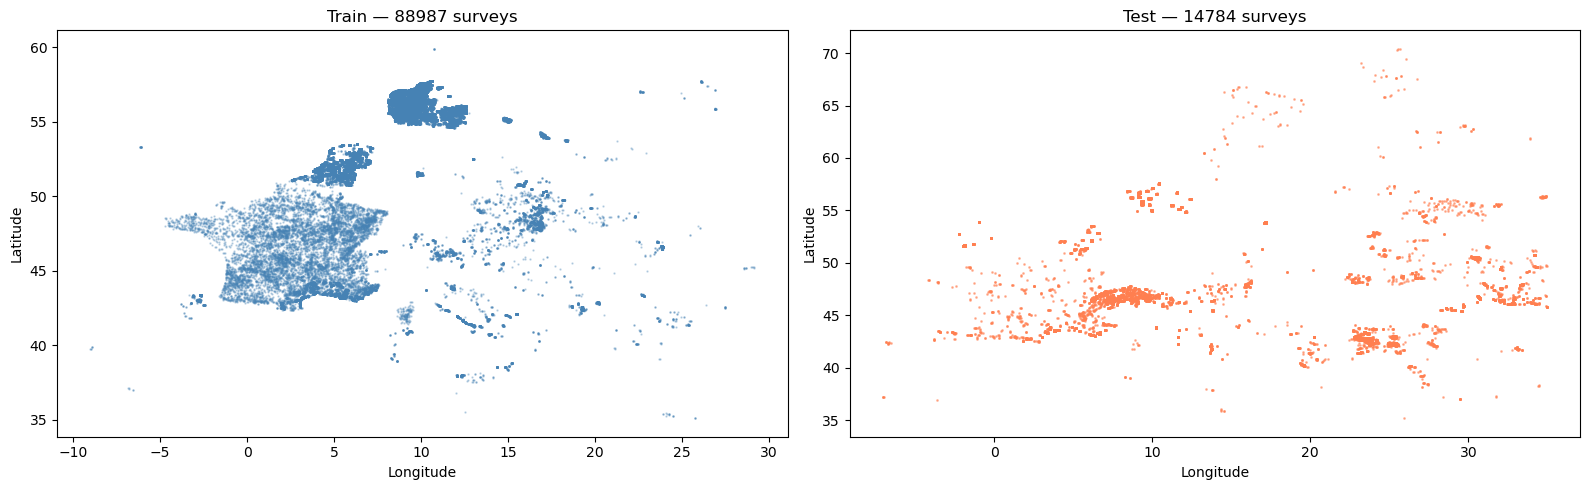

In [9]:
# Surveys uniques (un point par surveyId)
surveys_train = train.drop_duplicates('surveyId')
surveys_test  = test.drop_duplicates('surveyId')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(surveys_train['lon'], surveys_train['lat'], s=0.5, alpha=0.3, c='steelblue')
axes[0].set_title(f'Train — {len(surveys_train)} surveys')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(surveys_test['lon'], surveys_test['lat'], s=1, alpha=0.5, c='coral')
axes[1].set_title(f'Test — {len(surveys_test)} surveys')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

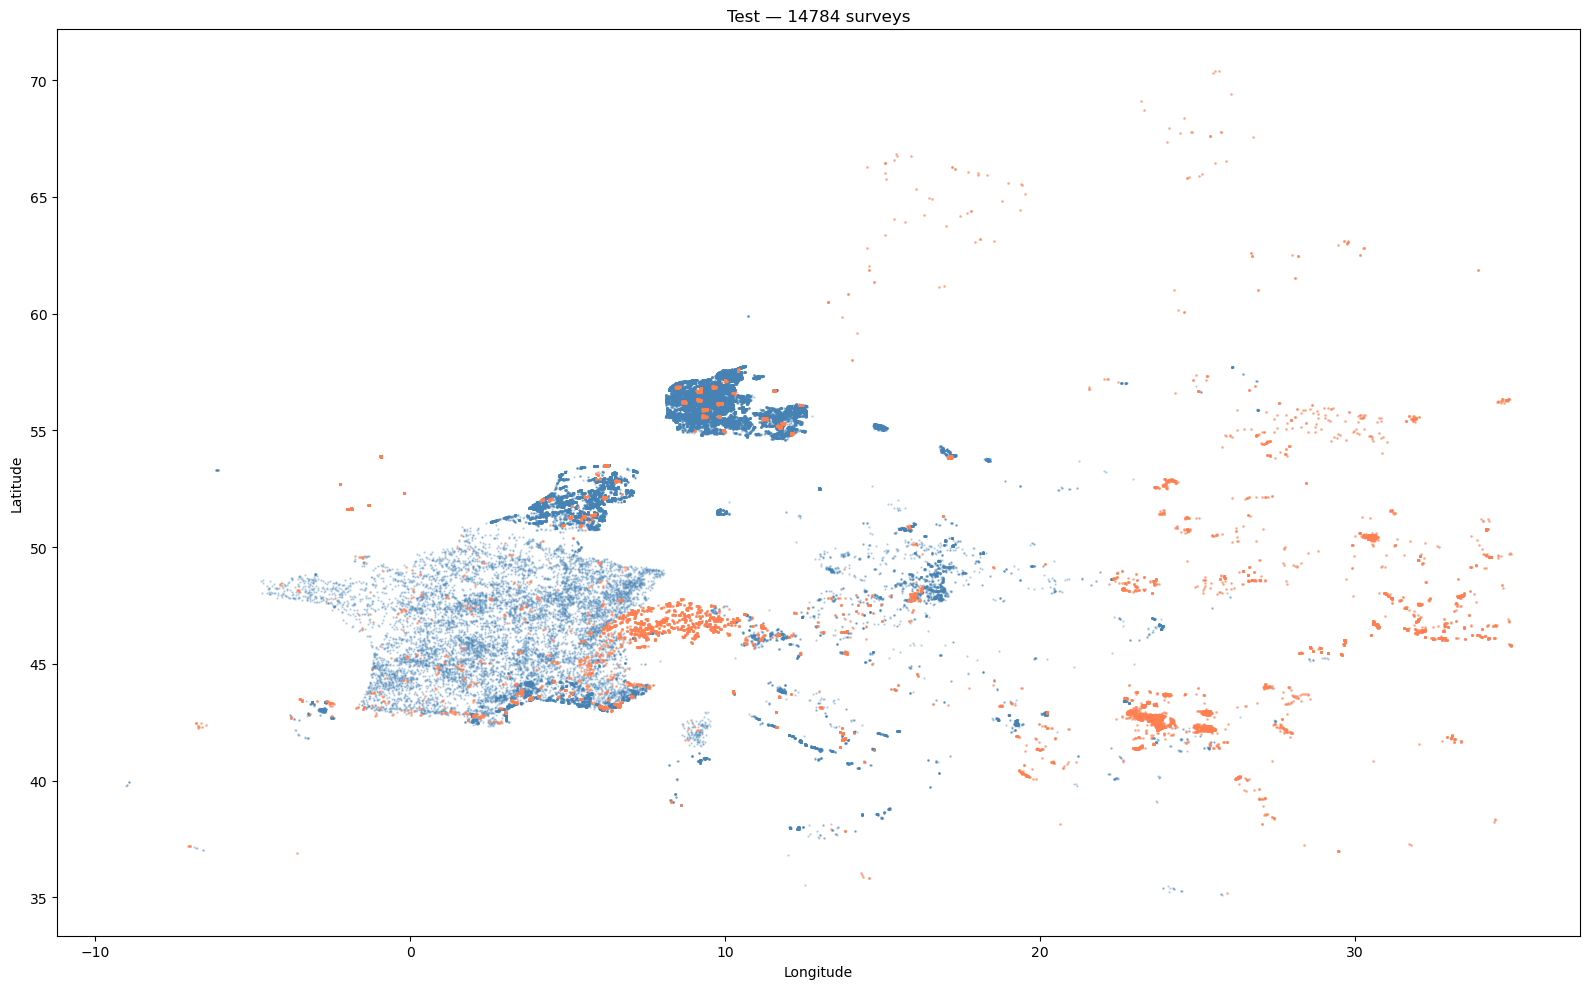

In [14]:
# Surveys uniques (un point par surveyId)
surveys_train = train.drop_duplicates('surveyId')
surveys_test  = test.drop_duplicates('surveyId')

fig, axes = plt.subplots(1, figsize=(16, 10))

axes.scatter(surveys_train['lon'], surveys_train['lat'], s=0.5, alpha=0.3, c='steelblue')
axes.set_title(f'Train — {len(surveys_train)} surveys')
axes.set_xlabel('Longitude')
axes.set_ylabel('Latitude')

axes.scatter(surveys_test['lon'], surveys_test['lat'], s=1, alpha=0.5, c='coral')
axes.set_title(f'Test — {len(surveys_test)} surveys')
axes.set_xlabel('Longitude')
axes.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 6. Répartition par région et pays

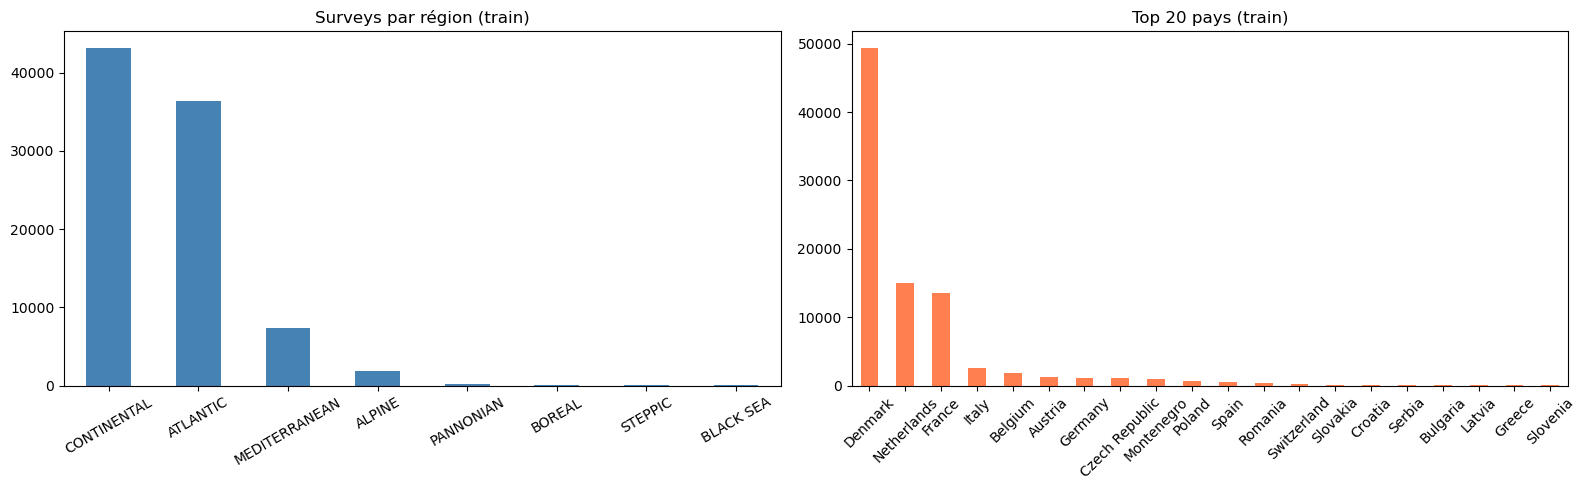

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

surveys_train['region'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Surveys par région (train)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

surveys_train['country'].value_counts().head(20).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 20 pays (train)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Distribution temporelle (années)

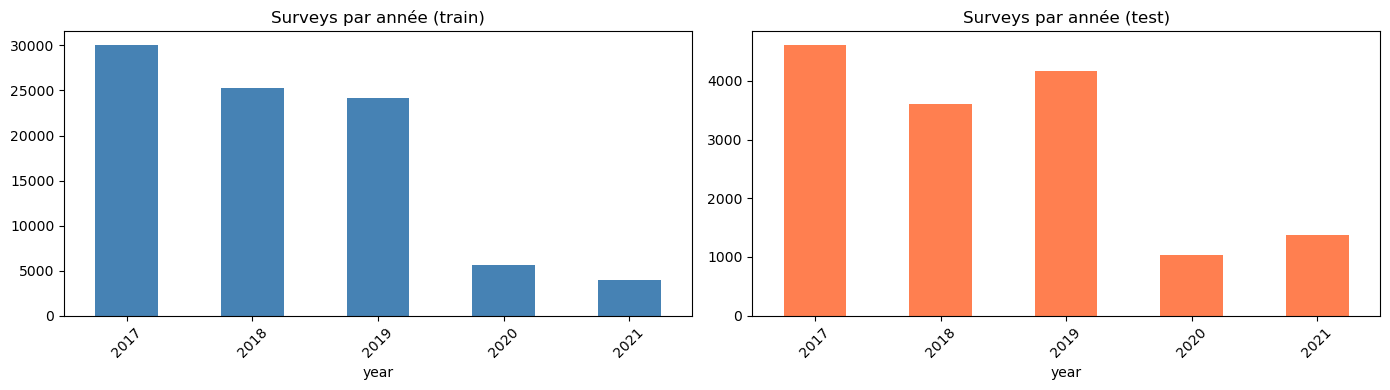

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

surveys_train['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Surveys par année (train)')
axes[0].tick_params(axis='x', rotation=45)

surveys_test['year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Surveys par année (test)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Incertitude géographique et surface

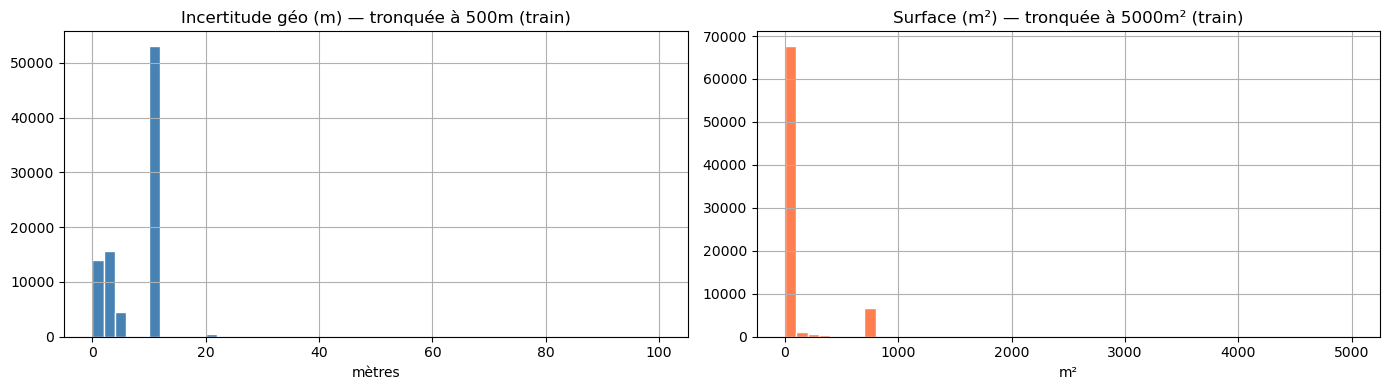

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

geo_vals = surveys_train['geoUncertaintyInM'].replace([np.inf, -np.inf], np.nan).dropna()
geo_vals.clip(upper=500).hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Incertitude géo (m) — tronquée à 500m (train)')
axes[0].set_xlabel('mètres')

area_vals = surveys_train['areaInM2'].replace([np.inf, -np.inf], np.nan).dropna()
area_vals.clip(upper=5000).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Surface (m²) — tronquée à 5000m² (train)')
axes[1].set_xlabel('m²')

plt.tight_layout()
plt.show()